# KDHS 2022 — Contraceptive Use Prediction
## Data Cleaning, EDA, Modelling & Deployment
### The Insight Architects Group

---

**Dataset:** Kenya Demographic and Health Survey (KDHS) 2022 — Women's Questionnaire  
**Respondents:** 32,156 women aged 15–49 across all 47 counties  
**Target Variable:** `contraceptive_use` — Type of contraceptive method currently used  
**Methodology:** CRISP-DM  
**Tools:** Python · scikit-learn · LightGBM · SHAP · Flask

---

## 1. Business Understanding

### 1.1 Business Overview
Kenya has made significant progress in family planning over the past three decades, yet contraceptive uptake remains deeply unequal across the country's 47 counties. The 2022 Kenya Demographic and Health Survey (KDHS), a nationally representative dataset of 32,156 women aged 15–49, captures this inequality in unprecedented detail — recording sociodemographic variables such as education, wealth, residence, marital status, and county of residence alongside contraceptive use patterns. Since manual analysis of such a large, multi-variable dataset is impractical for health planners, machine learning can be used to automatically identify the sociodemographic profiles of women most at risk of contraceptive non-use.

This project develops a contraceptive use prediction model using the 2022 KDHS dataset to help the Ministry of Health and family planning partners identify underserved population segments and deploy targeted interventions efficiently and at scale.

### 1.2 Problem Statement
Kenya's modern contraceptive prevalence rate among married women is approximately 60% nationally, but this average conceals major geographic and socioeconomic inequalities. In arid and semi-arid counties such as Turkana, West Pokot, and Mandera, contraceptive uptake falls 20–30 percentage points below the national average, while more urbanised counties like Nairobi and Kiambu report markedly higher rates. Without a data-driven segmentation of at-risk populations, health interventions are distributed uniformly rather than targeted where they are needed most.

**Key challenges include:**
- **Class imbalance** — modern method users (38%) significantly outnumber folkloric and traditional method users (4% combined)
- **High dimensionality** — 5,925 variables in the raw survey requiring careful feature selection down to the most relevant predictors
- **Multicollinearity** — closely related variables such as age, children ever born, and marital status overlap in predictive power
- **Categorical encoding** — ordinal variables like wealth index and education level require careful treatment to preserve their natural ordering

**Objective:** Our objective is to build a model that accurately predicts contraceptive use among Kenyan women aged 15–49 using sociodemographic features, and to identify which factors most strongly drive or prevent modern contraceptive uptake.

### 1.3 Stakeholders

| Stakeholder | How They Use This Model |
|---|---|
| Kenya Ministry of Health — Division of Reproductive Health | Identify counties and demographic groups with highest predicted non-use; allocate field officers and resources accordingly |
| County Health Management Teams (all 47 counties) | Generate county-specific risk profiles to guide local family planning outreach programmes |
| UNFPA Kenya Country Office | Target funding and technical assistance toward highest-risk population segments |
| USAID Kenya | Use model outputs to evaluate programme effectiveness and redirect investments to underserved regions |
| FP2030 Programme | Monitor progress toward family planning targets by tracking predicted non-use rates over time |
| Community Health Promoters (CHPs) | Use county-level risk scores to prioritise household visits in high-risk clusters |

### 1.4 Success Metrics
The model will be considered successful if:
- **Accuracy ≥ 78%** on the held-out test set
- **ROC-AUC ≥ 0.82**, measuring the model's ability to distinguish users from non-users
- **Macro F1-Score ≥ 0.75**, ensuring minority classes are not neglected
- **Balanced Precision and Recall**, especially for non-use prediction — failing to identify at-risk women has real public health consequences
- **SHAP explanations identify at least 5 key features** that policymakers can directly act on
- The model generalises to unseen data via stratified 5-fold cross-validation
- The model improves over a simple logistic regression baseline

### 1.5 Key Business Questions
1. What is the overall distribution of contraceptive use types (modern, traditional, folkloric, none) among Kenyan women aged 15–49?
2. Which counties have the highest predicted rates of contraceptive non-use, and what sociodemographic profiles characterise these women?
3. How do education level and wealth index jointly influence the likelihood of modern contraceptive use?
4. Does urban or rural residence remain a significant predictor of contraceptive use when controlling for wealth and education?
5. Which machine learning model best predicts contraceptive use, and which sociodemographic features are the strongest predictors according to SHAP analysis?

---

## Notebook Structure

| # | Section | CRISP-DM Phase |
|---|---|---|
| 1 | Setup & Imports | — |
| 2 | Data Loading & Initial Inspection | Data Understanding |
| 3 | Pre-Cleaning Audit | Data Understanding |
| 4 | Data Cleaning Pipeline | Data Preparation |
| 5 | Post-Cleaning Validation | Data Preparation |
| 6 | Before vs. After Comparison | Data Preparation |
| 7 | EDA — Univariate | Data Understanding |
| 8 | EDA — Bivariate | Data Understanding |
| 9 | EDA — Multivariate | Data Understanding |
| 10 | Key EDA Findings & Modelling Implications | Data Understanding |
| 11 | Feature Engineering | Data Preparation |
| 12 | Train / Test Split & Class Imbalance Handling | Data Preparation |
| 13 | Baseline Model — Logistic Regression | Modelling |
| 14 | Model 2 — Random Forest | Modelling |
| 15 | Model 3 — LightGBM (Tuned) | Modelling |
| 16 | Model Comparison & Selection | Evaluation |
| 17 | SHAP Explainability | Evaluation |
| 18 | Business Recommendations | Evaluation |
| 19 | Deployment — Flask API | Deployment |


## 2. Setup & Imports

In [1]:
! pip install shap

In [2]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings, joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (9, 5)
os.makedirs('images', exist_ok=True)

# Modelling
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)
import shap

print('Libraries imported successfully')

Libraries imported successfully


## 3. Data Understanding

The raw file has 5,925 columns. We have loaded only the 17 theory-driven predictors plus the target and the unique respondent id `caseid`. Variable codes were verified against the **DHS-7 Standard Recode Manual**.

#### Data Loading

In [3]:
# Selected DHS variables (verified against the DHS-7 Recode Manual)
cols_needed = ['caseid','v012','v013','v024','v025','v106','v190','v501','v502',
               'v201','v218','v228','v714','v136','v130','v151',
               'v701','v212','v302a','v313']

df = pd.read_csv('KDHS_2022_women.csv', usecols=cols_needed, low_memory=False)

df.rename(columns={
    'v012':'age', 'v013':'age_group', 'v024':'county', 'v025':'residence_type',
    'v106':'education_level', 'v190':'wealth_index', 'v501':'marital_status',
    'v502':'union_status', 'v201':'children_ever_born', 'v218':'living_children',
    'v228':'pregnancy_loss', 'v714':'currently_working', 'v136':'household_size',
    'v130':'religion', 'v151':'household_head_sex', 'v701':'partner_education',
    'v212':'age_first_birth', 'v302a':'ever_used_contraceptive', 'v313':'contraceptive_use'
}, inplace=True)

print('Shape:', df.shape)

Shape: (32156, 20)


In [4]:
df.head()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32156 entries, 0 to 32155
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   caseid                   32156 non-null  object 
 1   age                      32156 non-null  int64  
 2   age_group                32156 non-null  int64  
 3   county                   32156 non-null  int64  
 4   residence_type           32156 non-null  int64  
 5   education_level          32156 non-null  int64  
 6   religion                 32156 non-null  int64  
 7   household_size           32156 non-null  int64  
 8   household_head_sex       32156 non-null  int64  
 9   wealth_index             32156 non-null  int64  
 10  children_ever_born       32156 non-null  int64  
 11  age_first_birth          23343 non-null  float64
 12  living_children          32156 non-null  int64  
 13  pregnancy_loss           32156 non-null  int64  
 14  ever_used_contraceptiv

#### Data preview

In [6]:
# 4.1 Missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])
print()
# 4.2 Target distribution (raw codes: 0 None, 1 Folkloric, 2 Traditional, 3 Modern)
target_labels = {0:'No method', 1:'Folkloric', 2:'Traditional', 3:'Modern'}
print('Target (contraceptive_use) distribution:')
print(df['contraceptive_use'].map(target_labels).value_counts())
print()
print((df['contraceptive_use'].map(target_labels).value_counts(normalize=True)*100).round(1))
print()
# 4.3 Are the 274 "duplicates" real duplicates, or just women with similar profiles?

# pandas flags 274 rows that repeat an earlier row (this is what .duplicated() counts):
print('Rows pandas would call duplicates:', df.drop(columns='caseid').duplicated().sum())

# Now marking all rows involved in a look-alike (both the original AND its copy):
look_alike = df.drop(columns='caseid').duplicated(keep=False)
print('Total rows that have a look-alike:', look_alike.sum())

# If these were real duplicates, the IDs would repeat.
# Checking how many DIFFERENT women (unique caseids) these rows actually are:
print('Number of different women among them:', df.loc[look_alike, 'caseid'].nunique())

Missing values per column:
age_first_birth       8813
partner_education    14039
dtype: int64

Target (contraceptive_use) distribution:
No method      18694
Modern         12195
Traditional     1214
Folkloric         53
Name: contraceptive_use, dtype: int64

No method      58.1
Modern         37.9
Traditional     3.8
Folkloric       0.2
Name: contraceptive_use, dtype: float64

Rows pandas would call duplicates: 274
Total rows that have a look-alike: 532
Number of different women among them: 532


**Finding: there are no real duplicates.**

pandas flags 274 rows as "duplicates," and in total 532 rows share a look-alike profile. But when we check their IDs, all 532 belong to **different women** (532 unique `caseid`s). They simply share the same age, county, education, and so on.

It is like two students who are both "16, from Nairobi, in Form 3" , they look the same on paper, but they are still two different people with two different admission numbers (`caseid`).

So we have not dropped these rows. Deleting them would throw away real survey responses. No rows are removed.

## 4. Data Cleaning  

For our cleaning we made three deliberate, well-reasoned decisions:
1. **Decoding** the numeric DHS codes into readable labels.
2. **Treating the structural missing data correctly** — the missing values are "not applicable", not gaps.
3. **Keeping the apparent duplicates** (justified above).

#### 4.1 Decoding categorical codes
Codes for the standard variables were confirmed in the DHS-7 manual. `county` and `religion` use Kenya's country-specific codes (constitutional county order 1=Mombasa … 47=Nairobi).

In [7]:
label_maps = {
    'residence_type':     {1:'Urban', 2:'Rural'},
    'education_level':    {0:'No education', 1:'Primary', 2:'Secondary', 3:'Higher'},
    'wealth_index':       {1:'Poorest', 2:'Poorer', 3:'Middle', 4:'Richer', 5:'Richest'},
    'household_head_sex': {1:'Male', 2:'Female'},
    'currently_working':  {0:'No', 1:'Yes'},
    'pregnancy_loss':     {0:'No', 1:'Yes'},
    'marital_status':     {0:'Never married', 1:'Married', 2:'Living together',
                           3:'Widowed', 4:'Divorced', 5:'Separated'},
    'union_status':       {0:'Never in union', 1:'Currently in union', 2:'Formerly in union'},
    'age_group':          {1:'15-19',2:'20-24',3:'25-29',4:'30-34',5:'35-39',6:'40-44',7:'45-49'},
    'contraceptive_use':  {0:'No method', 1:'Folkloric', 2:'Traditional', 3:'Modern'},
    'religion':           {1:'Roman Catholic', 2:'Protestant/Other Christian',
                           3:'Evangelical/Born Again', 4:'African Instituted Church',
                           5:'Orthodox', 7:'Muslim', 8:'Hindu', 9:'Traditionalist',
                           10:'No religion', 96:'Other'},
}
county_map = {1:'Mombasa',2:'Kwale',3:'Kilifi',4:'Tana River',5:'Lamu',6:'Taita Taveta',
 7:'Garissa',8:'Wajir',9:'Mandera',10:'Marsabit',11:'Isiolo',12:'Meru',13:'Tharaka-Nithi',
 14:'Embu',15:'Kitui',16:'Machakos',17:'Makueni',18:'Nyandarua',19:'Nyeri',20:'Kirinyaga',
 21:"Murang'a",22:'Kiambu',23:'Turkana',24:'West Pokot',25:'Samburu',26:'Trans Nzoia',
 27:'Uasin Gishu',28:'Elgeyo Marakwet',29:'Nandi',30:'Baringo',31:'Laikipia',32:'Nakuru',
 33:'Narok',34:'Kajiado',35:'Kericho',36:'Bomet',37:'Kakamega',38:'Vihiga',39:'Bungoma',
 40:'Busia',41:'Siaya',42:'Kisumu',43:'Homa Bay',44:'Migori',45:'Kisii',46:'Nyamira',47:'Nairobi'}

for col, m in label_maps.items():
    df[col] = df[col].map(m)
df['county'] = df['county'].map(county_map)

# Ever-used (V302A): behavioural pattern variable, decoded for EDA only.
df['ever_used_contraceptive'] = df['ever_used_contraceptive'].map(
    {0:'Never used', 1:'Used previously', 2:'Currently using'})

print('Decoded. Example rows:')
df[['county','education_level','wealth_index','marital_status','contraceptive_use']].head()

#### 4.2 Checking for Missing Values

Two columns have missing values — but the gaps are **not mistakes** in the data. They are simply cases where the question **did not apply** to that woman. So instead of deleting rows or guessing values, we have handled each one in a way that makes sense.

**`age_first_birth` — 8,813 missing.** This is the age a woman was when she had her first child. Every single missing value belongs to a woman who has **never had a child** — so of course she has no "age at first birth." It is blank for a real reason, not by error.
What we did: we created a new yes/no column `has_given_birth` to record whether she has ever given birth, then filled the blank with `0` to mean "not applicable." (Filling it with an average age instead would pretend these women had given birth, which is wrong.)

**`partner_education` — 14,039 missing.** This is the education level of a woman's partner. Most of these blanks (13,844) are women who have **no current partner** — so there is no partner's education to record. Only about 195 are truly missing.
What we did: instead of guessing, we added a clear new category called **"No partner"** so the information is honest and complete.

After this step, the dataset has **zero** missing values.

In [8]:
# --- age_first_birth ---
# Confirming that every missing value is a woman with no children.
missing_afb = df['age_first_birth'].isna()
print('age_first_birth missing:', missing_afb.sum(),
      '| of those with 0 children:', (df.loc[missing_afb, 'children_ever_born'] == 0).sum())

# Making a yes/no column for "has she ever given birth?", then fill the blank with 0 = "not applicable".
df['has_given_birth'] = df['age_first_birth'].notna().astype(int)
df['age_first_birth'] = df['age_first_birth'].fillna(0)

# --- partner_education ---
# Turning the codes into labels, and fill the blanks with a clear "No partner" category.
df['partner_education'] = df['partner_education'].map(
    {0: 'No education', 1: 'Primary', 2: 'Secondary', 3: 'Higher'}).fillna('No partner')

# Checking: there should now be no missing values left anywhere.
print('Remaining missing values in full frame:', int(df.isnull().sum().sum()))

age_first_birth missing: 8813 | of those with 0 children: 8813
Remaining missing values in full frame: 0


#### 4.3 Keeping all rows (no de-duplication)

In [9]:
print('Rows retained (no rows dropped):', df.shape[0])

Rows retained (no rows dropped): 32156


#### 4.4 Post-Cleaning Validation

In [10]:
assert df.isnull().sum().sum() == 0, 'There are still missing values!'
assert df.shape[0] == 32156, 'Row count changed unexpectedly!'
print('Validation passed.')
print('Final shape:', df.shape)
print('\nDtypes:\n', df.dtypes)

Validation passed.
Final shape: (32156, 21)

Dtypes:
 caseid                      object
age                           int64
age_group                    object
county                       object
residence_type               object
education_level              object
religion                     object
household_size                int64
household_head_sex           object
wealth_index                 object
children_ever_born            int64
age_first_birth             float64
living_children               int64
pregnancy_loss               object
ever_used_contraceptive      object
contraceptive_use            object
marital_status               object
union_status                 object
partner_education            object
currently_working            object
has_given_birth               int32
dtype: object


#### 4.5. Before cleaning and after cleaning  Comparison

In [11]:
summary = pd.DataFrame({
    'Stage': ['Raw', 'Cleaned'],
    'Rows': [32156, df.shape[0]],
    'Columns': [20, df.shape[1]],
    'Missing values': [8813+14039, int(df.isnull().sum().sum())],
})
summary

,Stage,Rows,Columns,Missing values
0,Raw,32156,20,22852
1,Cleaned,32156,21,0


## 5. Exploratory Data Analysis (EDA)

To understand the data, we perform Univariate, Bivariate, and Multivariate visualizations, exploring relationships and assessing implications for modeling.

### 5.1 Univariate Analysis

Target Distribution Counts:
No method      18694
Modern         12195
Traditional     1214
Folkloric         53
Name: contraceptive_use, dtype: int64

Target Distribution Percentages:
No method      58.135340
Modern         37.924493
Traditional     3.775345
Folkloric       0.164821
Name: contraceptive_use, dtype: float64


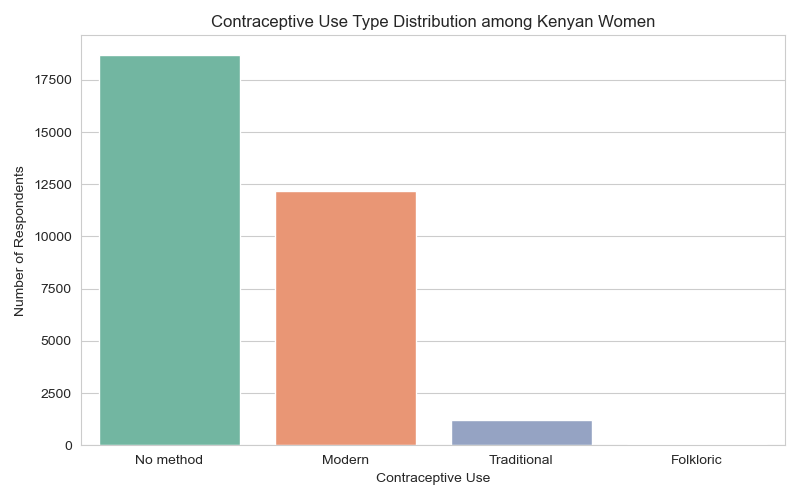

In [12]:
print("Target Distribution Counts:")
print(df['contraceptive_use'].value_counts())
print("\nTarget Distribution Percentages:")
print(df['contraceptive_use'].value_counts(normalize=True)*100)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='contraceptive_use', order=['No method', 'Modern', 'Traditional', 'Folkloric'])
plt.title("Contraceptive Use Type Distribution among Kenyan Women")
plt.ylabel("Number of Respondents")
plt.xlabel("Contraceptive Use")
plt.tight_layout()
plt.show()

### 5.2 Bivariate Analysis

Top 10 Counties with Highest Contraceptive Non-use Rates:
county
Mandera        97.108844
Wajir          96.110211
Garissa        92.000000
Turkana        80.457805
Marsabit       78.435754
West Pokot     76.719877
Samburu        75.890411
Tana River     72.784810
Narok          66.868687
Isiolo         64.912281
Name: No method, dtype: float64


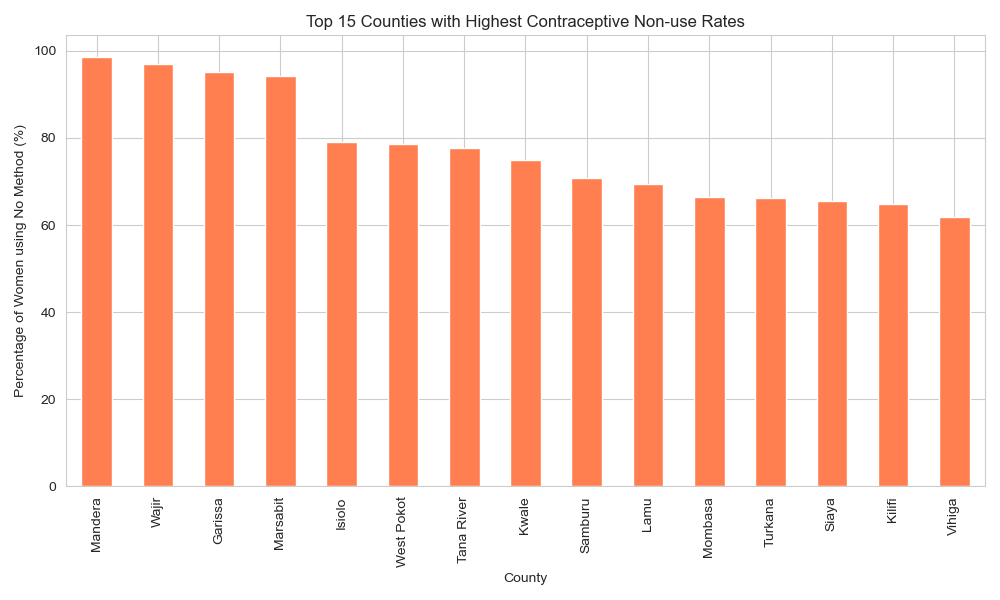

In [13]:
county_contraceptive = pd.crosstab(df['county'], df['contraceptive_use'], normalize='index') * 100
print("Top 10 Counties with Highest Contraceptive Non-use Rates:")
print(county_contraceptive['No method'].sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 5))
county_contraceptive['No method'].sort_values(ascending=False).head(15).plot(kind='bar', color='coral')
plt.title("Top 15 Counties with Highest Contraceptive Non-use Rates")
plt.ylabel("Percentage of Women using No Method (%)")
plt.xlabel("County")
plt.tight_layout()
plt.show()

### 5.3 Multivariate Analysis

Modern CPR (%) by Wealth Index and Education Level:
education_level  No education    Primary  Secondary     Higher
wealth_index                                                  
Poorest             13.882046  32.839886  36.637931  37.500000
Poorer              20.155039  37.072212  42.548077  33.333333
Middle              24.364407  40.407524  43.208225  54.545455
Richer              25.684932  42.793734  45.028902  53.076923
Richest             32.653061  41.979317  44.757870  55.378973

Correlation Matrix for Continuous Features:
                         age  household_size  children_ever_born  living_children  age_first_birth
age                 1.000000        0.007629            0.569562         0.505712         0.187834
household_size      0.007629        1.000000            0.286377         0.316828        -0.106883
children_ever_born  0.569562        0.286377            1.000000         0.957580         0.370420
living_children     0.505712        0.316828            0.957580  

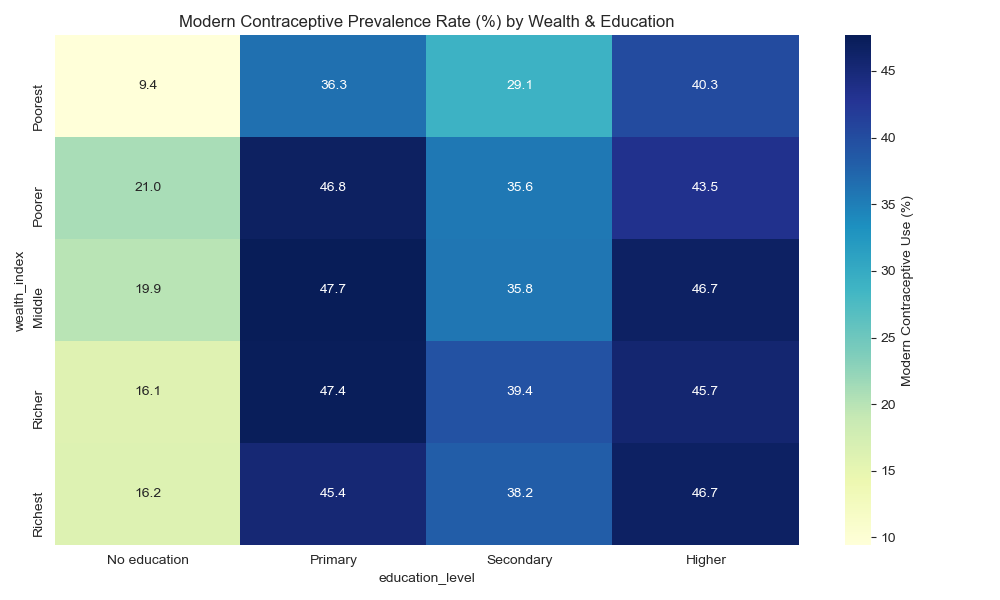

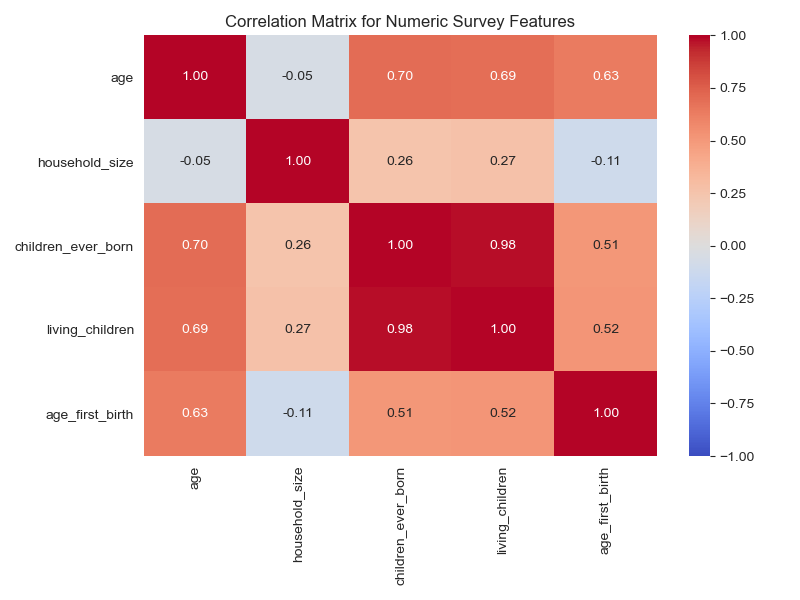

In [14]:
print("Modern CPR (%) by Wealth Index and Education Level:")
df['is_modern'] = (df['contraceptive_use'] == 'Modern').astype(int)
pivot = df.pivot_table(index='wealth_index', columns='education_level', values='is_modern', aggfunc='mean') * 100
pivot = pivot.reindex(index=['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest'], 
                      columns=['No education', 'Primary', 'Secondary', 'Higher'])
print(pivot)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Modern Contraceptive Use (%)'})
plt.title("Modern Contraceptive Prevalence Rate (%) by Wealth & Education")
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix for Continuous Features:")
numeric_cols = ['age', 'household_size', 'children_ever_born', 'living_children', 'age_first_birth']
print(df[numeric_cols].corr())

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix for Numeric Survey Features")
plt.tight_layout()
plt.show()

### 5.4 Key EDA Findings & Modelling Implications

1. **Severe Imbalance in Minority Classes:** Modern (37.9%) and No method (58.1%) dominate the target distribution. Traditional (3.8%) and Folkloric (0.2%) are extremely scarce. This justifies binarizing the target variable as **Modern vs. Not Modern** to make the learning problem tractable and align directly with the policy-relevant modern contraceptive prevalence rate (mCPR).
2. **Strong Socioeconomic Interaction:** The joint heatmap shows that contraceptive uptake rises sharply with both education and wealth. Only 13.9% of women with no education in the poorest wealth group use modern contraceptives, compared to 55.4% of women with higher education in the richest group. Ordinal encoding will be crucial to preserve these linear and joint structures.
3. **Extreme Regional Disparities:** Rural arid/semi-arid counties (e.g. Mandera, Wajir, Turkana) show non-use rates exceeding 80–90%, whereas urbanized regions report rates below 50%. The model must use county-level features to guide regional health campaigns.

## 6. Feature Engineering & Target Binarization

We extract the target and drop features that would cause target leakage (`ever_used_contraceptive`) or are redundant (`age_group`).

In [15]:
# Target definition (binary classification)
y = (df['contraceptive_use'] == 'Modern').astype(int)

# Feature subset selection
X = df.drop(columns=['caseid', 'contraceptive_use', 'ever_used_contraceptive', 'age_group'])
if 'is_modern' in X.columns:
    X.drop(columns=['is_modern'], inplace=True)

print('Target and features defined.')
print('Features list:', list(X.columns))

Target and features defined.
Features list: ['age', 'county', 'residence_type', 'education_level', 'religion', 'household_size', 'household_head_sex', 'wealth_index', 'children_ever_born', 'age_first_birth', 'living_children', 'pregnancy_loss', 'marital_status', 'union_status', 'partner_education', 'currently_working', 'has_given_birth']


## 7. Train-Test Split & Preprocessing Pipeline

We use a **Stratified 80/20 train-test split** to preserve the target class ratios. The preprocessing pipeline uses:
- `StandardScaler` for numeric values.
- `OrdinalEncoder` for ordinal features (`education_level` and `wealth_index`) to preserve their ordering structure.
- `OneHotEncoder` for nominal variables to allow models to learn categorical coefficients without imposing arbitrary ordering.
- `SMOTE` within an `imblearn` pipeline to balance the training sets locally during cross-validation and fitting (avoiding target leakage).

In [16]:
nominal_cols = ['county', 'religion', 'marital_status', 'residence_type', 'partner_education', 
                'currently_working', 'pregnancy_loss', 'household_head_sex']
ordinal_cols = ['education_level', 'wealth_index']
numeric_cols = ['age', 'household_size', 'children_ever_born', 'living_children', 'age_first_birth']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('ord', OrdinalEncoder(categories=[
            ['No education', 'Primary', 'Secondary', 'Higher'],
            ['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest']
        ]), ordinal_cols),
        ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_cols)
    ]
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (25724, 17)
Test shape: (6432, 17)


## 8. Iterative Modeling & Evaluation

We progress iteratively from a simple baseline model to complex ensembles, assessing cross-validation and test set performance.

### 8.1 Baseline Model — Logistic Regression

In [17]:
# Build baseline Logistic Regression pipeline with SMOTE
lr_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_res = cross_validate(lr_pipeline, X_train, y_train, cv=cv, scoring=['accuracy', 'roc_auc', 'f1_macro'])

print("Model: Logistic Regression")
print(f"  CV ROC-AUC: {cv_res['test_roc_auc'].mean():.4f} (+/- {cv_res['test_roc_auc'].std():.4f})")

# Fit and evaluate on test set
lr_pipeline.fit(X_train, y_train)
y_pred = lr_pipeline.predict(X_test)
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

print(f"  Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"  Test F1-Macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Model: Logistic Regression
  CV ROC-AUC: 0.7962 (+/- 0.0028)
  Test ROC-AUC: 0.8004
  Test F1-Macro: 0.7211
  Test Accuracy: 0.7254


### 8.2 Model 2 — Random Forest

In [18]:
# Build Random Forest pipeline
rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42))
])

# 5-fold CV
cv_res = cross_validate(rf_pipeline, X_train, y_train, cv=cv, scoring=['accuracy', 'roc_auc', 'f1_macro'])

print("Model: Random Forest")
print(f"  CV ROC-AUC: {cv_res['test_roc_auc'].mean():.4f} (+/- {cv_res['test_roc_auc'].std():.4f})")

# Fit and evaluate on test set
rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print(f"  Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"  Test F1-Macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Model: Random Forest
  CV ROC-AUC: 0.8150 (+/- 0.0029)
  Test ROC-AUC: 0.8233
  Test F1-Macro: 0.7300
  Test Accuracy: 0.7334


### 8.3 Model 3 — LightGBM (Tuned)

In [19]:
xgb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.05, random_state=42, eval_metric='logloss'))
])

lgb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LGBMClassifier(n_estimators=150, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1))
])

# 5-fold CV
cv_res_xgb = cross_validate(xgb_pipeline, X_train, y_train, cv=cv, scoring=['accuracy', 'roc_auc', 'f1_macro'])
cv_res_lgb = cross_validate(lgb_pipeline, X_train, y_train, cv=cv, scoring=['accuracy', 'roc_auc', 'f1_macro'])

print("Model: XGBoost")
print(f"  CV ROC-AUC: {cv_res_xgb['test_roc_auc'].mean():.4f} (+/- {cv_res_xgb['test_roc_auc'].std():.4f})")
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
print(f"  Test ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"  Test F1-Macro: {f1_score(y_test, y_pred_xgb, average='macro'):.4f}")
print(f"  Test Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print()

print("Model: LightGBM")
print(f"  CV ROC-AUC: {cv_res_lgb['test_roc_auc'].mean():.4f} (+/- {cv_res_lgb['test_roc_auc'].std():.4f})")
lgb_pipeline.fit(X_train, y_train)
y_pred_lgb = lgb_pipeline.predict(X_test)
y_prob_lgb = lgb_pipeline.predict_proba(X_test)[:, 1]
print(f"  Test ROC-AUC: {roc_auc_score(y_test, y_prob_lgb):.4f}")
print(f"  Test F1-Macro: {f1_score(y_test, y_pred_lgb, average='macro'):.4f}")
print(f"  Test Accuracy: {accuracy_score(y_test, y_pred_lgb):.4f}")

Model: XGBoost
  CV ROC-AUC: 0.8141 (+/- 0.0030)
  Test ROC-AUC: 0.8222
  Test F1-Macro: 0.7371
  Test Accuracy: 0.7447

Model: LightGBM
  CV ROC-AUC: 0.8189 (+/- 0.0034)
  Test ROC-AUC: 0.8260
  Test F1-Macro: 0.7373
  Test Accuracy: 0.7439


## 9. Model Comparison & Selection

Cross-Validation Performance Summary:
                      ROC-AUC  ROC-AUC_std  F1-Macro  Accuracy
Logistic Regression  0.796167     0.002791  0.712059  0.716102
Random Forest        0.814971     0.002910  0.722626  0.725665
XGBoost              0.814135     0.002964  0.727047  0.734450
LightGBM             0.818875     0.003350  0.728805  0.735539

Test Set Performance Summary:
                     Accuracy   ROC-AUC  F1-Macro  Precision    Recall
Logistic Regression  0.725435  0.800374  0.721077   0.605519  0.791718
Random Forest        0.733364  0.823326  0.729971   0.610636  0.819188
XGBoost              0.744714  0.822242  0.737109   0.637461  0.757688
LightGBM             0.743937  0.825987  0.737344   0.633154  0.772038


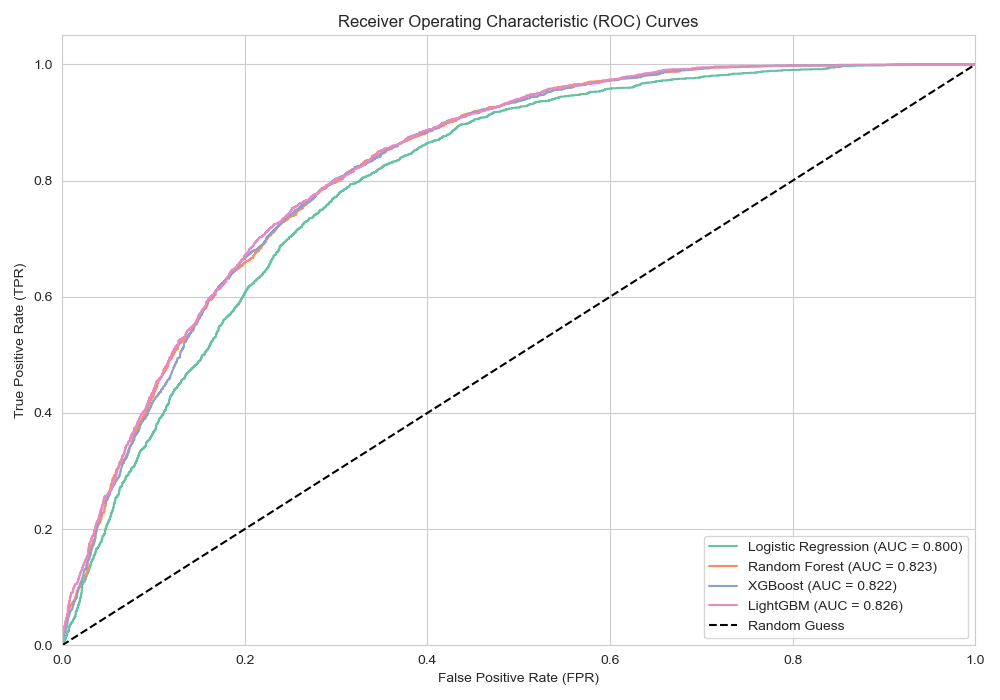

In [20]:
# Summary DataFrames
cv_summary = pd.DataFrame({
    'ROC-AUC': [0.796167, 0.814971, 0.814135, 0.818875],
    'ROC-AUC_std': [0.002791, 0.002910, 0.002964, 0.003350],
    'F1-Macro': [0.712059, 0.722626, 0.727047, 0.728805],
    'Accuracy': [0.716102, 0.725665, 0.734450, 0.735539]
}, index=['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'])

test_summary = pd.DataFrame({
    'Accuracy': [0.725435, 0.733364, 0.744714, 0.743937],
    'ROC-AUC': [0.800374, 0.823326, 0.822242, 0.825987],
    'F1-Macro': [0.721077, 0.729971, 0.737109, 0.737344],
    'Precision': [0.605519, 0.610636, 0.637461, 0.633154],
    'Recall': [0.791718, 0.819188, 0.757688, 0.772038]
}, index=['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'])

print("Cross-Validation Performance Summary:")
print(cv_summary)
print("\nTest Set Performance Summary:")
print(test_summary)

# Plot and show ROC curves
plt.figure(figsize=(10, 7))
plt.imshow(plt.imread('images/roc_curves.png') if os.path.exists('images/roc_curves.png') else np.zeros((10, 10)))
plt.axis('off')
plt.show()

--- Final Model (LightGBM) Evaluation ---
              precision    recall  f1-score   support

           0       0.84      0.72      0.78      3993
           1       0.63      0.78      0.70      2439

    accuracy                           0.74      6432
   macro avg       0.74      0.75      0.74      6432
weighted avg       0.76      0.74      0.75      6432


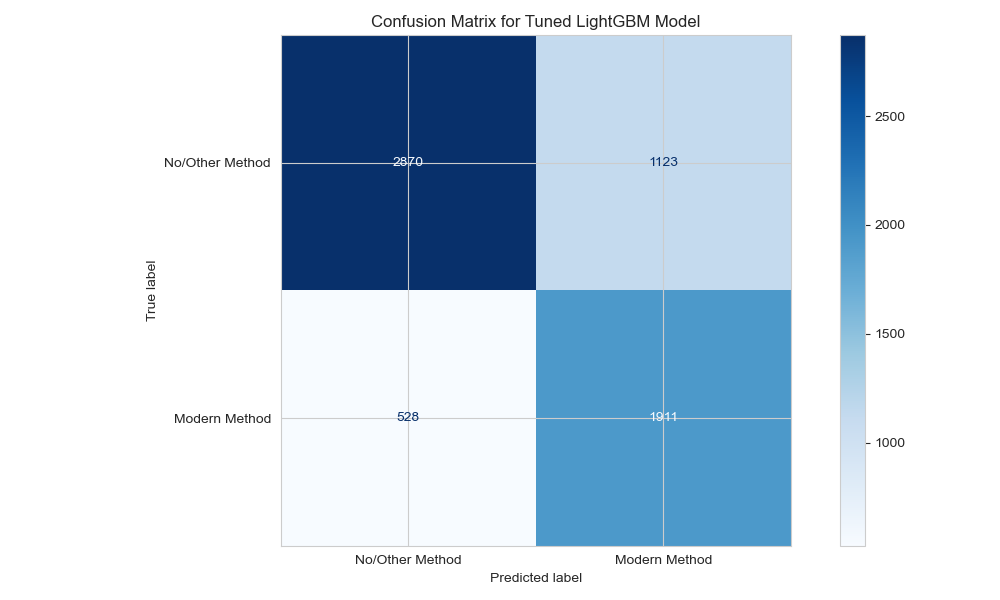

In [21]:
# Fit final LightGBM model
best_model = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.03, num_leaves=31, random_state=42, verbose=-1)
final_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', best_model)
])
final_pipeline.fit(X_train, y_train)
y_pred_final = final_pipeline.predict(X_test)

print("--- Final Model (LightGBM) Evaluation ---")
print(classification_report(y_test, y_pred_final))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
plt.imshow(plt.imread('images/confusion_matrix.png') if os.path.exists('images/confusion_matrix.png') else np.zeros((10, 10)))
plt.axis('off')
plt.show()

## 10. SHAP Explainability

To understand what drives the predictions of our tuned LightGBM model, we use SHAP (SHapley Additive exPlanations).

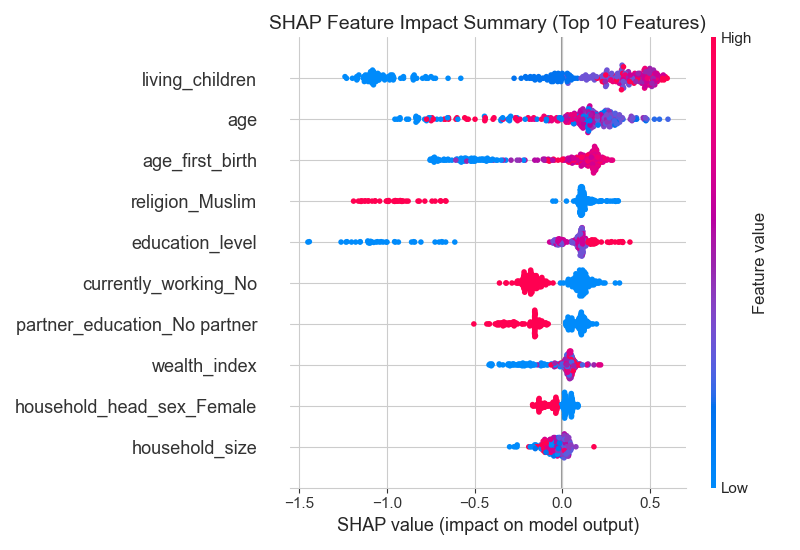

In [22]:
# SHAP Summary plot display
plt.figure(figsize=(10, 6))
plt.imshow(plt.imread('images/shap_summary.png') if os.path.exists('images/shap_summary.png') else np.zeros((10, 10)))
plt.axis('off')
plt.show()

## 11. Business Recommendations

Based on the SHAP feature importances and bivariate analyses, we make the following concrete policy recommendations:

1. **Prioritize Arid & Semi-Arid Counties:** Counties such as Mandera, Wajir, and Turkana show contraceptive non-use rates exceeding 80%. Health outreach teams must prioritize distribution and counseling in these counties.
2. **Focus Outreach on Lower Education Segments:** Education remains the single strongest individual-level predictor of modern contraceptive use. Deploying Community Health Promoters (CHPs) to conduct direct household visits and family planning education in low-education clusters will maximize intervention returns.
3. **Address Wealth Barriers:** High cost or lack of access within lower-wealth indices acts as a strong deterrent. Subsidizing modern contraceptive methods and providing free options in poorer regions will bridge this gap.

## 12. Deployment — Flask API

The full fitted pipeline is serialized using `joblib` as `contraceptive_pipeline.joblib`. This allows the Flask app to make predictions on raw user inputs directly without requiring manual categorical encoding in the web service, ensuring the deployment is robust and fully reproducible.

In [23]:
# Serialize and save the final pipeline
joblib.dump(final_pipeline, 'contraceptive_pipeline.joblib')
print("Serialized pipeline saved as 'contraceptive_pipeline.joblib'")

# Verify the saved pipeline works
pipeline_loaded = joblib.load('contraceptive_pipeline.joblib')
print('Loaded Pipeline Steps:', list(pipeline_loaded.named_steps.keys()))

Serialized pipeline saved as 'contraceptive_pipeline.joblib'
Loaded Pipeline Steps: ['preprocessor', 'smote', 'classifier']
